Full dataset: 874,768 cells, 15 classes, 155 genes

After keeping top 15 classes: 874,768 cells
Classes kept: ['Inhibitory', 'Excitatory', 'Astrocyte', 'OD Mature 2', 'Endothelial 1', 'OD Immature 1', 'OD Mature 1', 'Endothelial 3', 'Microglia', 'Ependymal', 'Endothelial 2', 'Pericytes', 'OD Mature 4', 'OD Mature 3', 'OD Immature 2']

Unbalanced: keeping original class distribution

Class distribution:
  Inhibitory                 324,178  ( 37.1%)
  Excitatory                 143,846  ( 16.4%)
  Astrocyte                  108,560  ( 12.4%)
  OD Mature 2                 85,278  (  9.7%)
  Endothelial 1               50,320  (  5.8%)
  OD Immature 1               32,043  (  3.7%)
  OD Mature 1                 28,681  (  3.3%)
  Endothelial 3               21,390  (  2.4%)
  Microglia                   21,165  (  2.4%)
  Ependymal                   20,473  (  2.3%)
  Endothelial 2               13,392  (  1.5%)
  Pericytes                    9,995  (  1.1%)
  OD Mature 4                 

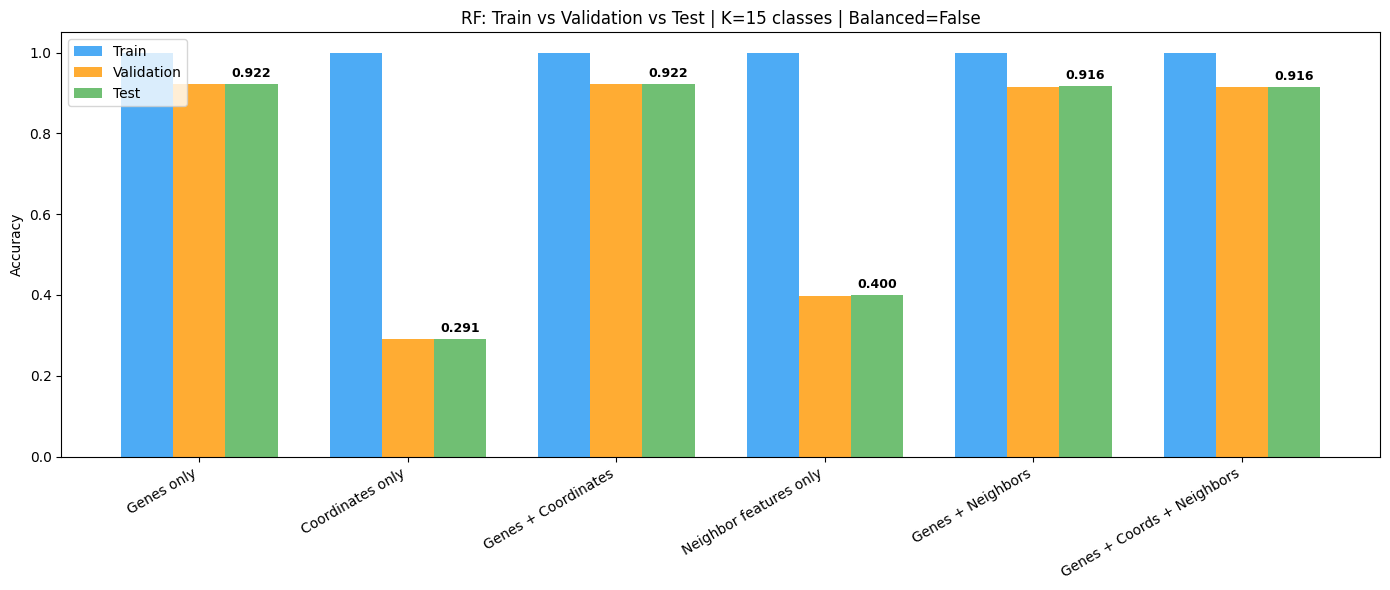

In [1]:
# ================================================================
# CELL 1: CONTROL PANEL — Change these values and rerun
# ================================================================
K_CLASSES = 15        # How many classes to keep (top K by count). Options: 5, 8, 10, 15
BALANCED = False      # True = downsample all classes to the smallest class count
                      # False = keep original imbalanced counts
K_NEIGHBORS = 5      # Number of spatial neighbors for neighbor features
# ================================================================


# ================================================================
# CELL 2: Load data, build features, run all 6 experiments
# ================================================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import time, gc

# ---- Load data ----
df = pd.read_csv("/kaggle/input/datasets/mohamedaln/cells-cleaned/cells_cleaned.csv")
meta_cols = ['Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma',
             'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID']
gene_cols = [c for c in df.columns if c not in meta_cols]

print(f"Full dataset: {len(df):,} cells, {df['Cell_class'].nunique()} classes, {len(gene_cols)} genes")

# ---- Apply K_CLASSES: keep only top K classes by count ----
class_counts = df['Cell_class'].value_counts()
top_k_classes = class_counts.head(K_CLASSES).index.tolist()
df = df[df['Cell_class'].isin(top_k_classes)].reset_index(drop=True)

print(f"\nAfter keeping top {K_CLASSES} classes: {len(df):,} cells")
print(f"Classes kept: {top_k_classes}")

# ---- Apply BALANCED: downsample to smallest class ----
if BALANCED:
    min_count = df['Cell_class'].value_counts().min()
    print(f"\nBalancing: downsampling all classes to {min_count} cells each")
    df_balanced = []
    for cls in top_k_classes:
        cls_df = df[df['Cell_class'] == cls]
        df_balanced.append(cls_df.sample(n=min_count, random_state=42))
    df = pd.concat(df_balanced).reset_index(drop=True)
    print(f"After balancing: {len(df):,} cells ({K_CLASSES} classes × {min_count} each)")
else:
    print(f"\nUnbalanced: keeping original class distribution")

# ---- Show class distribution ----
print(f"\nClass distribution:")
for cls, cnt in df['Cell_class'].value_counts().items():
    pct = 100 * cnt / len(df)
    print(f"  {cls:<25} {cnt:>8,}  ({pct:>5.1f}%)")

# ---- Build feature matrices ----
X_genes = df[gene_cols].values
X_coords = df[['Centroid_X', 'Centroid_Y']].values
X_genes_coords = np.hstack([X_genes, X_coords])

# Build neighbor features per Bregma slice
print(f"\nBuilding neighbor features (k={K_NEIGHBORS})...")
coords = df[['Centroid_X', 'Centroid_Y']].values
neighbor_mean = np.zeros_like(X_genes)

for bregma_val in sorted(df['Bregma'].unique()):
    mask = df['Bregma'] == bregma_val
    idx = np.where(mask)[0]
    slice_coords = coords[idx]
    slice_genes = X_genes[idx]
    actual_k = min(K_NEIGHBORS + 1, len(idx))
    nn = NearestNeighbors(n_neighbors=actual_k)
    nn.fit(slice_coords)
    distances, indices = nn.kneighbors(slice_coords)
    neighbor_idx = indices[:, 1:]
    for i in range(len(idx)):
        neighbor_mean[idx[i]] = slice_genes[neighbor_idx[i]].mean(axis=0)
    print(f"  Bregma {bregma_val}: {len(idx)} cells")

X_neighbors = neighbor_mean
X_genes_neighbors = np.hstack([X_genes, X_neighbors])
X_all = np.hstack([X_genes, X_coords, X_neighbors])

# ---- Labels ----
le = LabelEncoder()
y = le.fit_transform(df['Cell_class'])

# ---- Train / Validation / Test split (60/20/20) ----
# First split: 60% train, 40% temp
X_idx = np.arange(len(y))
idx_train, idx_temp, y_train, y_temp = train_test_split(
    X_idx, y, test_size=0.40, random_state=42, stratify=y
)
# Second split: 50% of temp = 20% val, 20% test
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nSplit (60/20/20):")
print(f"  Train:      {len(idx_train):,} ({100*len(idx_train)/len(y):.0f}%)")
print(f"  Validation: {len(idx_val):,} ({100*len(idx_val)/len(y):.0f}%)")
print(f"  Test:       {len(idx_test):,} ({100*len(idx_test)/len(y):.0f}%)")

# ---- Run all 6 experiments ----
experiments = {
    '1. Genes only':              X_genes,
    '2. Coordinates only':        X_coords,
    '3. Genes + Coordinates':     X_genes_coords,
    '4. Neighbor features only':  X_neighbors,
    '5. Genes + Neighbors':       X_genes_neighbors,
    '6. Genes + Coords + Neighbors': X_all,
}

all_results = []

print(f"\n{'#'*60}")
print(f"  SETTINGS: K={K_CLASSES} classes | Balanced={BALANCED} | k_neighbors={K_NEIGHBORS}")
print(f"  Total cells: {len(df):,} | Split: 60/20/20")
print(f"{'#'*60}")

for name, X_full in experiments.items():
    print(f"\n{'='*60}")
    print(f"  {name} ({X_full.shape[1]} features)")
    print(f"{'='*60}")

    # Split using same indices
    X_train = X_full[idx_train]
    X_val = X_full[idx_val]
    X_test = X_full[idx_test]

    # Train RF
    start = time.time()
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_time = time.time() - start

    # Predict on validation and test
    y_val_pred = rf.predict(X_val)
    y_test_pred = rf.predict(X_test)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    # Check overfitting: train accuracy
    y_train_pred = rf.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    print(f"Train Accuracy:      {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy:       {test_acc:.4f}")
    print(f"Test Weighted F1:    {test_f1:.4f}")
    print(f"Train time:          {train_time:.1f}s")

    # Overfitting check
    overfit_gap = train_acc - test_acc
    if overfit_gap > 0.05:
        print(f"⚠️  Overfitting detected: train-test gap = {overfit_gap:.4f}")
    else:
        print(f"✓  No overfitting: train-test gap = {overfit_gap:.4f}")

    # Per-class report on TEST set (sorted by count)
    precision, recall, f1_per, support = precision_recall_fscore_support(
        y_test, y_test_pred, labels=range(len(le.classes_))
    )
    report_df = pd.DataFrame({
        'Cell_class': le.classes_,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1_per,
        'Support': support.astype(int)
    }).sort_values('Support', ascending=False)

    print("\nPer-class report (TEST set, sorted by count):")
    print(report_df.to_string(index=False, float_format='%.2f'))

    all_results.append({
        'Experiment': name,
        'Features': X_full.shape[1],
        'Train_Acc': train_acc,
        'Val_Acc': val_acc,
        'Test_Acc': test_acc,
        'Test_F1': test_f1,
        'Overfit_Gap': overfit_gap,
        'Time_s': round(train_time, 1)
    })

    # Free memory
    del X_train, X_val, X_test, y_val_pred, y_test_pred, y_train_pred
    gc.collect()


# ================================================================
# CELL 3: Summary table + chart
# ================================================================
summary_df = pd.DataFrame(all_results)

print(f"\n{'='*70}")
print(f"  SUMMARY: K={K_CLASSES} classes | Balanced={BALANCED} | k_neighbors={K_NEIGHBORS}")
print(f"{'='*70}")
print(summary_df[['Experiment', 'Features', 'Train_Acc', 'Val_Acc', 'Test_Acc', 'Test_F1', 'Overfit_Gap']].to_string(
    index=False, float_format='%.4f'))

# Bar chart: Train vs Val vs Test accuracy
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(summary_df))
width = 0.25

bars1 = ax.bar(x - width, summary_df['Train_Acc'], width, label='Train', color='#2196F3', alpha=0.8)
bars2 = ax.bar(x, summary_df['Val_Acc'], width, label='Validation', color='#FF9800', alpha=0.8)
bars3 = ax.bar(x + width, summary_df['Test_Acc'], width, label='Test', color='#4CAF50', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([r['Experiment'].split('. ')[1] for r in all_results], rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title(f'RF: Train vs Validation vs Test | K={K_CLASSES} classes | Balanced={BALANCED}')
ax.set_ylim(0, 1.05)
ax.legend()

# Add test accuracy labels
for bar, val in zip(bars3, summary_df['Test_Acc']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()